Value Iteration

In [7]:
from matplotlib import pyplot as plt
import numpy as np

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

Iterations: 370
[[0.41462779 0.42719345 0.44613759 0.46831093 0.49243541 0.51656243
  0.53525442 0.54096824]
 [0.41167365 0.42119567 0.43748456 0.45837858 0.48323145 0.51352455
  0.54576111 0.55736187]
 [0.39673907 0.3938281  0.37548492 0.         0.42167062 0.49381213
  0.56120588 0.58585299]
 [0.36925938 0.35297059 0.30652149 0.2003984  0.30074688 0.
  0.56901037 0.62825378]
 [0.33264451 0.291362   0.19730131 0.         0.28928572 0.36194762
  0.5348147  0.68969305]
 [0.30611159 0.         0.         0.08627432 0.21392932 0.27271094
  0.         0.77203252]
 [0.28885711 0.         0.05769018 0.0475082  0.         0.25052014
  0.         0.87776719]
 [0.28035854 0.20079143 0.12731113 0.         0.23959037 0.48644111
  0.73710281 0.        ]]


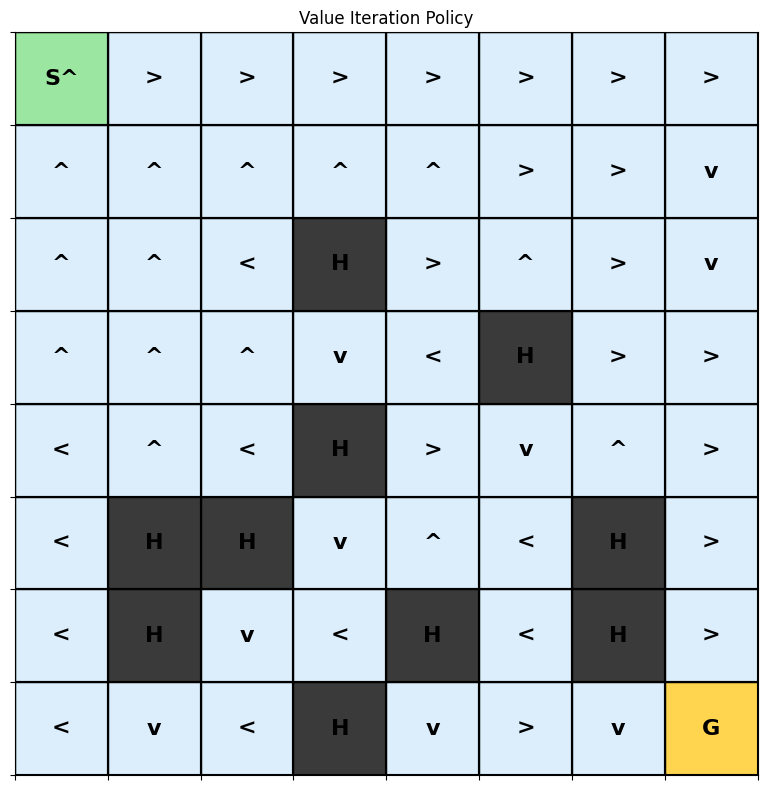

In [12]:
import gymnasium as gym
import numpy as np

env = gym.make(
    "FrozenLake-v1",
    map_name="8x8",
    is_slippery=True
)

P = env.unwrapped.P

n_states = env.observation_space.n
n_actions = env.action_space.n

gamma = 0.99
theta = 1e-6

V = np.zeros(n_states)

iterations = 0

while True:
    iterations += 1

    delta = 0
    new_V = V.copy()

    for state in range(n_states):
        values = []

        for action in range(n_actions):
            total = 0

            for prob, next_state, reward, done in P[state][action]:
                total += prob * (reward + gamma * V[next_state])

            values.append(total)

        new_V[state] = max(values)
        delta = max(delta, abs(new_V[state] - V[state]))

    V = new_V

    if delta < theta:
        break

policy = np.zeros(n_states, dtype=int)

for state in range(n_states):
    values = []

    for action in range(n_actions):
        total = 0

        for prob, next_state, reward, done in P[state][action]:
            total += prob * (reward + gamma * V[next_state])

        values.append(total)

    policy[state] = np.argmax(values)

print("Iterations:", iterations)
print(V.reshape(8, 8))

plot_policy_on_frozen_lake(
    env,
    policy,
    title="Value Iteration Policy"
)

Policy Iteration

Iterations: 11
[[0.41463976 0.42720468 0.44614774 0.46831994 0.49244333 0.51656949
  0.53526119 0.5409749 ]
 [0.41168583 0.42120729 0.43749523 0.45838812 0.48323975 0.51353145
  0.54576756 0.55736812]
 [0.39675151 0.39384001 0.3754958  0.         0.42167765 0.49381889
  0.56121181 0.58585865]
 [0.36927172 0.35298204 0.30653083 0.20040347 0.30075244 0.
  0.56901564 0.62825882]
 [0.33265847 0.29137309 0.19730829 0.         0.28928993 0.36195153
  0.53481922 0.68969715]
 [0.30612679 0.         0.         0.08627587 0.21393223 0.27271369
  0.         0.7720354 ]
 [0.28887316 0.         0.05769354 0.0475099  0.         0.25052137
  0.         0.87776868]
 [0.28037506 0.2008042  0.12731955 0.         0.23959082 0.48644198
  0.73710326 0.        ]]


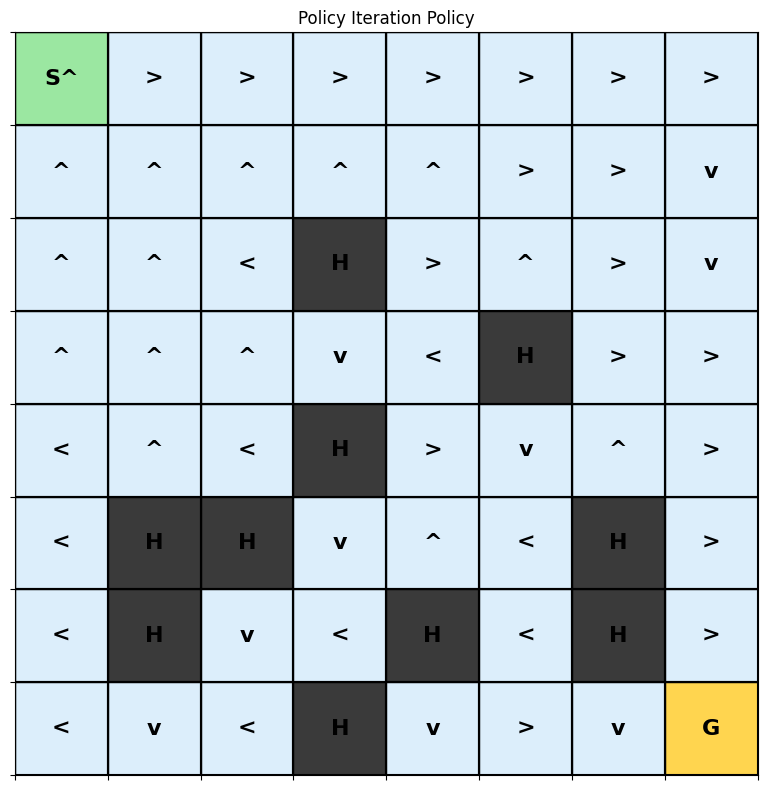

In [13]:
import gymnasium as gym
import numpy as np

env = gym.make(
    "FrozenLake-v1",
    map_name="8x8",
    is_slippery=True
)

P = env.unwrapped.P

n_states = env.observation_space.n
n_actions = env.action_space.n

gamma = 0.99
theta = 1e-6

policy = np.zeros(n_states, dtype=int)
V = np.zeros(n_states)

iterations = 0

while True:
    iterations += 1

    while True:
        delta = 0

        for state in range(n_states):
            old_v = V[state]

            action = policy[state]

            value = 0

            for prob, next_state, reward, done in P[state][action]:
                value += prob * (reward + gamma * V[next_state])

            V[state] = value

            delta = max(delta, abs(old_v - V[state]))

        if delta < theta:
            break

    stable = True

    for state in range(n_states):
        old_action = policy[state]

        action_values = []

        for action in range(n_actions):
            value = 0

            for prob, next_state, reward, done in P[state][action]:
                value += prob * (reward + gamma * V[next_state])

            action_values.append(value)

        best_action = np.argmax(action_values)
        policy[state] = best_action

        if best_action != old_action:
            stable = False

    if stable:
        break

print("Iterations:", iterations)
print(V.reshape(8, 8))

plot_policy_on_frozen_lake(
    env,
    policy,
    title="Policy Iteration Policy"
)

Matrix Method

Iterations: 11
[[ 0.415  0.427  0.446  0.468  0.492  0.517  0.535  0.541]
 [ 0.412  0.421  0.437  0.458  0.483  0.514  0.546  0.557]
 [ 0.397  0.394  0.375  0.     0.422  0.494  0.561  0.586]
 [ 0.369  0.353  0.307  0.2    0.301  0.     0.569  0.628]
 [ 0.333  0.291  0.197 -0.     0.289  0.362  0.535  0.69 ]
 [ 0.306  0.     0.     0.086  0.214  0.273  0.     0.772]
 [ 0.289 -0.     0.058  0.048  0.     0.251  0.     0.878]
 [ 0.28   0.201  0.127 -0.     0.24   0.486  0.737  0.   ]]


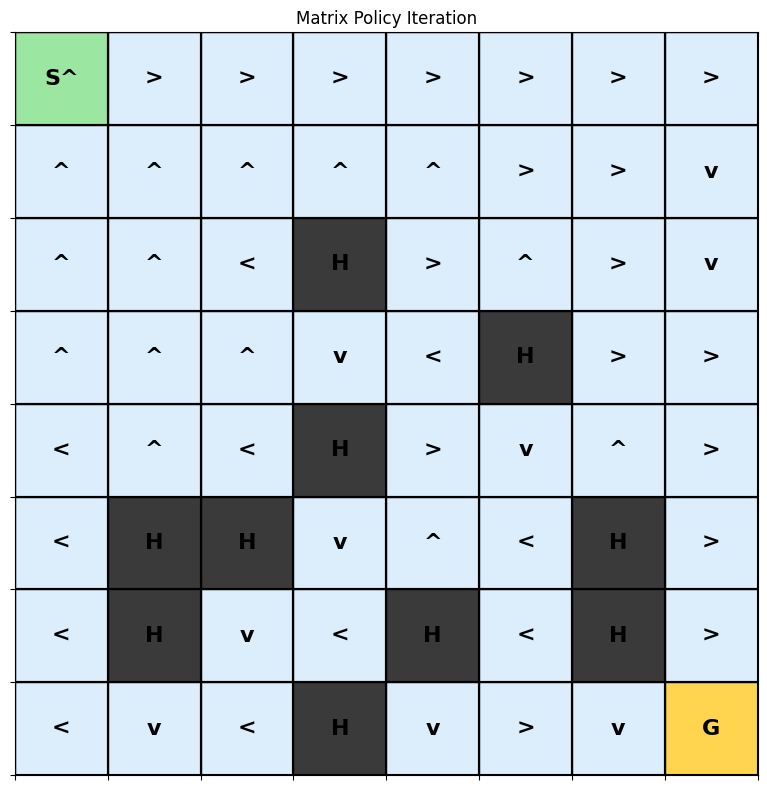

In [15]:
import gymnasium as gym
import numpy as np

env = gym.make(
    "FrozenLake-v1",
    map_name="8x8",
    is_slippery=True
)

P = env.unwrapped.P

n_states = env.observation_space.n
n_actions = env.action_space.n

gamma = 0.99

policy = np.zeros(n_states, dtype=int)

iterations = 0

while True:
    iterations += 1

    P_pi = np.zeros((n_states, n_states))
    R_pi = np.zeros(n_states)

    for state in range(n_states):
        action = policy[state]

        for prob, next_state, reward, done in P[state][action]:
            P_pi[state, next_state] += prob
            R_pi[state] += prob * reward

    V = np.linalg.solve(
        np.eye(n_states) - gamma * P_pi,
        R_pi
    )

    stable = True

    for state in range(n_states):
        old_action = policy[state]

        best_action = old_action
        best_value = -np.inf

        for action in range(n_actions):
            value = 0

            for prob, next_state, reward, done in P[state][action]:
                value += prob * (
                    reward + gamma * V[next_state]
                )

            if value > best_value + 1e-12:
                best_value = value
                best_action = action

        policy[state] = best_action

        if best_action != old_action:
            stable = False

    if stable:
        break

print("Iterations:", iterations)
print(np.round(V.reshape(8, 8), 3))

plot_policy_on_frozen_lake(
    env,
    policy,
    title="Matrix Policy Iteration"
)